# **Why GNN+MLP**
- Dengue operates through two independent mechanisms — spatial spread across borders (GNN) and state-level temporal dynamics (MLP) — no single architecture captures both

- Standalone MLP is structurally blind to correlated neighbor outbreaks regardless of data quality

- Standalone GNN risks diluting individual state seasonality into neighborhood averages during message passing

- Hybrid runs both in parallel, fusion layer learns the optimal balance between both paths dynamically per sample

- Strong performance of both models is partly because the dataset is feature-rich — climate, vegetation, socioeconomic, and demographic signals gave each node meaningful information to communicate during message passing

- A GNN on weak features propagates noise across the graph — good dataset was a necessary condition for GNN to add value here

- Empirically validated — MLP alone R² = 0.9194, Hybrid R² = 0.9464, confirming graph reasoning added genuine complementary signal. And Had the datset been weak then GNN would have faced over-smoothing.

⚙️ Processing Data...
🚀 Starting Hybrid Training...
Epoch 50 | Loss: 0.2404
Epoch 100 | Loss: 0.2209
Epoch 150 | Loss: 0.2145
Epoch 200 | Loss: 0.2130
Epoch 250 | Loss: 0.1965
Epoch 300 | Loss: 0.1903
Epoch 350 | Loss: 0.1883
Epoch 400 | Loss: 0.1868

📊 FINAL HYBRID RESULTS:
MAE: 987
R²: 0.9464


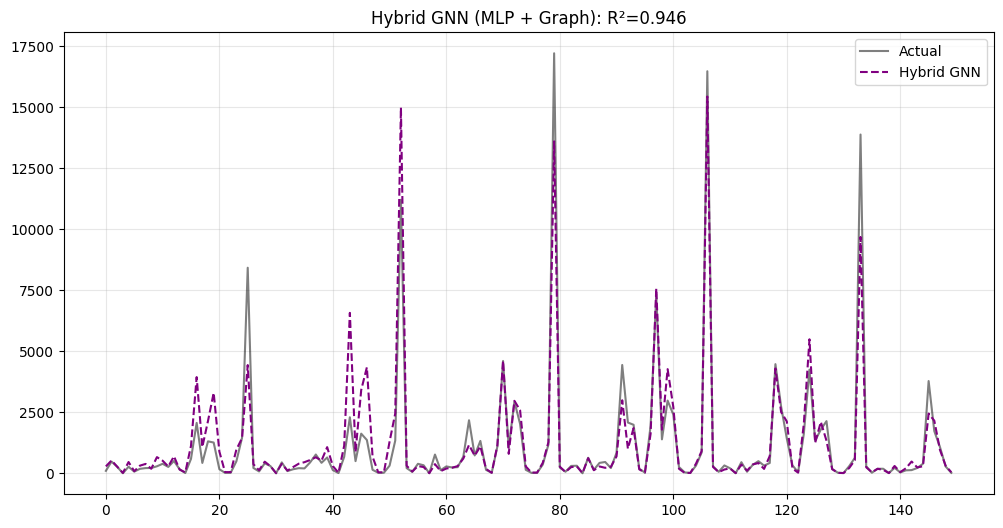

In [ ]:
# ==========================================
# FINAL MASTER BLOCK: HYBRID GNN (MLP + GNN + DATA)
# ==========================================
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# --- 1. AUTO-INSTALL ---
try:
    import torch_geometric
except ImportError:
    os.environ['TORCH'] = torch.__version__
    !pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
    !pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
    !pip install -q torch-geometric
    import torch_geometric

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATv2Conv
import torch.nn.functional as F
import torch.nn as nn

# --- 2. DATA PROCESSING (PAPER-GRADE) ---
print("⚙️ Processing Data...")
df = pd.read_csv('Brazil_UF_dengue_monthly.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by=['Date', 'CD_UF'])

# Log Target
df['cases_log'] = np.log1p(df['cases_total'])

# Features (Short & Long Term)
df['cases_lag1'] = df.groupby('CD_UF')['cases_log'].shift(1)
df['cases_lag12'] = df.groupby('CD_UF')['cases_log'].shift(12) # Yearly Memory
df['precip_lag1'] = df.groupby('CD_UF')['total_precipitation_d'].shift(1)
df['temp_lag1'] = df.groupby('CD_UF')['temperature_2m_d'].shift(1)
df['cases_rolling_3'] = df.groupby('CD_UF')['cases_log'].transform(lambda x: x.rolling(3).mean().shift(1))
df['precip_rolling_3'] = df.groupby('CD_UF')['total_precipitation_d'].transform(lambda x: x.rolling(3).mean().shift(1))
df['month_sin'] = np.sin(2 * np.pi * df['Date'].dt.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df['Date'].dt.month / 12)

df = df.dropna()

feature_cols = [
    'cases_lag1', 'cases_rolling_3', 'cases_lag12',
    'precip_lag1', 'precip_rolling_3',
    'temp_lag1',
    'month_sin', 'month_cos',
    'PopTotal_UF'
]

# Strict Scaling
train_mask = df['Year'] < 2018
scaler = StandardScaler()
scaler.fit(df.loc[train_mask, feature_cols])
df[feature_cols] = scaler.transform(df[feature_cols])

# Build Graph
adjacency_map = {
    11: [13, 51], 12: [13], 13: [12, 11, 51, 15, 14], 14: [13, 15], 15: [16, 13, 51, 52, 17, 21],
    16: [15], 17: [15, 51, 52, 29, 22, 21], 21: [15, 17, 22], 22: [21, 17, 29, 26, 23],
    23: [22, 26, 25, 24], 24: [23, 25], 25: [24, 23, 26], 26: [22, 23, 25, 27, 29],
    27: [26, 28, 29], 28: [27, 29], 29: [27, 28, 26, 22, 17, 52, 31, 32], 31: [29, 52, 50, 35, 33, 32],
    32: [29, 31, 33], 33: [32, 31, 35], 35: [33, 31, 50, 41], 41: [35, 50, 42],
    42: [41, 43], 43: [42], 50: [51, 52, 31, 35, 41], 51: [11, 13, 15, 17, 52, 50],
    52: [51, 17, 29, 31, 50, 53], 53: [52]
}
sorted_ufs = sorted(df['CD_UF'].unique())
uf_to_idx = {uf: i for i, uf in enumerate(sorted_ufs)}
sources, targets = [], []
for uf, neighbors in adjacency_map.items():
    if uf in uf_to_idx:
        for neighbor in neighbors:
            if neighbor in uf_to_idx:
                sources.append(uf_to_idx[uf])
                targets.append(uf_to_idx[neighbor])
edge_index = torch.tensor([sources, targets], dtype=torch.long)

# Snapshots
graph_snapshots = []
for date in df['Date'].unique():
    monthly_data = df[df['Date'] == date].sort_values(by='CD_UF')
    x = torch.tensor(monthly_data[feature_cols].values, dtype=torch.float)
    y = torch.tensor(monthly_data['cases_log'].values, dtype=torch.float).view(-1, 1)
    graph_snapshots.append(Data(x=x, edge_index=edge_index, y=y))

split_idx = len(df[df['Year'] < 2018]['Date'].unique())
train_dataset = graph_snapshots[:split_idx]
test_dataset = graph_snapshots[split_idx:]

train_loader = DataLoader(train_dataset, batch_size=12, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)

# --- 3. HYBRID MODEL (MLP + GNN) ---
class HybridGNN(nn.Module):
    def __init__(self, input_dim):
        super(HybridGNN, self).__init__()

        # Path A: GNN (Spatial)
        self.gat1 = GATv2Conv(input_dim, 128, heads=4, dropout=0.1)
        self.gat2 = GATv2Conv(128*4, 64, heads=2, dropout=0.1)

        # Path B: MLP (Temporal/History)
        self.mlp_in = nn.Linear(input_dim, 128)
        self.mlp_mid = nn.Linear(128, 128)

        # Fusion
        self.fusion = nn.Linear(128 + 128, 64)
        self.out = nn.Linear(64, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # GNN Path
        g = self.gat1(x, edge_index)
        g = F.elu(g)
        g = F.dropout(g, p=0.2, training=self.training)
        g = self.gat2(g, edge_index)
        g = F.elu(g)

        # MLP Path
        m = self.mlp_in(x)
        m = F.elu(m)
        m = self.mlp_mid(m)
        m = F.elu(m)

        # Combine
        combined = torch.cat([g, m], dim=1)
        out = self.fusion(combined)
        out = F.elu(out)
        return self.out(out)

model = HybridGNN(input_dim=len(feature_cols))

# --- 4. TRAINING LOOP ---
optimizer = torch.optim.Adam(model.parameters(), lr=0.002, weight_decay=1e-4)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15)

print("🚀 Starting Hybrid Training...")
epochs = 400
best_loss = float('inf')
best_weights = copy.deepcopy(model.state_dict())

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        out = model(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    scheduler.step(avg_loss)

    if avg_loss < best_loss:
        best_loss = avg_loss
        best_weights = copy.deepcopy(model.state_dict())

    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f}")

# --- 5. EVALUATION ---
model.load_state_dict(best_weights)
model.eval()
all_preds, all_actuals = [], []

with torch.no_grad():
    for batch in test_loader:
        pred_log = model(batch)
        actual_log = batch.y
        all_preds.append(pred_log.cpu().numpy())
        all_actuals.append(actual_log.cpu().numpy())

pred_real = np.expm1(np.concatenate(all_preds))
actual_real = np.expm1(np.concatenate(all_actuals))

mae = np.mean(np.abs(pred_real - actual_real))
r2 = r2_score(np.concatenate(all_actuals), np.concatenate(all_preds))

print(f"\n📊 FINAL HYBRID RESULTS:")
print(f"MAE: {mae:.0f}")
print(f"R²: {r2:.4f}")

plt.figure(figsize=(12, 6))
plt.plot(actual_real[:150], label='Actual', color='black', alpha=0.5)
plt.plot(pred_real[:150], label='Hybrid GNN', color='purple', linestyle='--')
plt.title(f'Hybrid GNN (MLP + Graph): R²={r2:.3f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()